# Part A

## Step 1: Set Up

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('Setup complete!')

Setup complete!


## Step 2: Understanding the LIF Equation

In [2]:
# The LIF equation (discrete time version):
#
# V[t+1] = V[t] + dt * ( -(V[t] - V_rest) / tau + I[t] / C )
#
# Where:
# V = membrane potential (voltage)
# V_rest = resting potential (what V returns to with no input)
# tau = membrane time constant (how fast voltage decays)
# I = input current
# C = membrane capacitance
# dt = time step size

## Step 3: Defining Neuron Parameters

In [3]:
# ============ Simulation Parameters ============
dt = 0.001          # Time step (1 ms)
T  = 1.0            # Total simulation time (1 second)
time = np.arange(0, T, dt)  # Time array

# ============ Neuron Parameters ============
V_rest    = -70.0    # Resting potential (mV)
V_thresh  = -55.0    # Spike threshold (mV)
V_reset   = -75.0    # Reset potential after spike (mV)
tau       =  0.020   # Membrane time constant (20 ms)
C         = 1.0      # Membrane capacitance (normalized)

print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


### Knowledge Check
1. Because after a real neuron fires an action potential, it undergoes hyperpolarization.
The membrane potential briefly becomes more negative than resting potential due to potassium ion outflow. Setting V_reset below V_rest simulates this biological refractory period.
2. The time constant tau controls how quickly the membrane potential returns to rest (how “leaky” the neuron is).
  - Small tau → voltage decays quickly (fast leak)
  - Large tau → voltage decays slowly (holds charge longer)

    Biologically, this reflects membrane resistance and capacitance properties.

## Step 4: Building the LIF Simulation

In [4]:
# ============ Input Current ============
I_input = np.zeros(len(time))
I_input[200:800] = 15.0  # Inject 15 nA from t=200ms to t=800ms

# ============ Storage Arrays ============
V = np.zeros(len(time))
V[0] = V_rest
spikes = []

# ============ Simulation Loop ============
for t in range(len(time) - 1):

    # TODO 1: Compute voltage change
    dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )

    # TODO 2: Update membrane potential
    V[t+1] = V[t] + dV

    # TODO 3: Threshold check
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 0 spikes


## Step 5: Visualizing the Membrane Potential

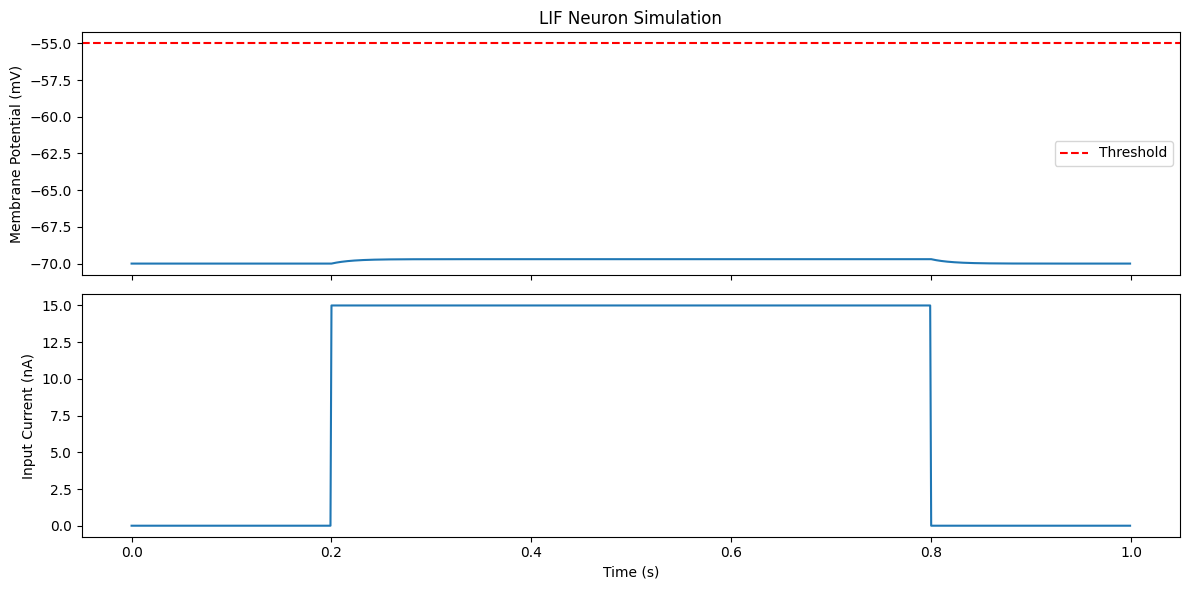

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot membrane potential
ax1.plot(time, V)
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')

ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# Plot input current
ax2.plot(time, I_input)
ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### Knowledge Check
1. In my implementation, the neuron never actually spikes—the membrane potential stays below threshold the entire time. However, during the current injection, 𝑉 still rises in a curved, exponential-like way rather than as a straight line. This curvature comes from the leak term −(𝑉−𝑉rest)/𝜏 , which continuously pulls the voltage back toward the resting potential while the input current pushes it upward.
2. After the current turns off at 𝑡=0.8s, the membrane potential decays smoothly back toward the resting potential of −70mV. This happens because, with no input current, the only remaining term in the LIF equation is the leak, which drives 𝑉 back to 𝑉rest over a timescale set by 𝜏.

### Reflection
The model captures realistic subthreshold integration and leak behavior seen in biological neurons i.e, when current is injected, the membrane potential depolarizes in a curved, exponential fashion, and when the current stops, it relaxes back toward rest. However, in my implementation the neuron never reaches threshold, so I do not see actual spikes or resets. That highlights how sensitive spiking behavior is to parameter choices and implementation details. Compared to real neurons,with complex ion channel dynamics, dendritic processing, and shaped action potentials—this LIF model is still very simplified, but it does illustrate how input, leak, and time constants shape voltage trajectories.

# Part B

## Step 6: Understanding Rate Coding

In [6]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains using rate coding.
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        random_vals = np.random.rand(num_neurons)
        spikes[t] = (random_vals < values).astype(float)

    return spikes

### Testing the Function

In [7]:
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 8 spikes in 200 steps
Value 0.3 -> 59 spikes in 200 steps
Value 0.5 -> 100 spikes in 200 steps
Value 0.7 -> 147 spikes in 200 steps
Value 0.9 -> 182 spikes in 200 steps


## Step 7: Understanding Temporal Coding

In [8]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes

### Knowledge Check
1. Rate coding preserves the average firing rate, which reflects the magnitude of the original value. A higher value produces more spikes per second, and a lower value produces fewer. However, it loses precise timing information. Individual spike times are random, so the exact temporal structure of the signal is not preserved. Two signals with the same mean intensity but different time dynamics can look identical under rate coding.
2. Temporal coding encodes information in when the spike occurs, not how many spikes occur. High-value inputs spike earlier, so a downstream neuron can infer the signal strength after a single spike, without waiting to average over many spikes. This makes temporal coding extremely fast which is ideal for circuits that need rapid responses (e.g., auditory localization
3. A classic example is sound localization in the auditory brainstem.
The brain determines where a sound is coming from by comparing microsecond-level timing differences between the ears (interaural time differences). The exact timing of the first spikes carries the crucial information, not the firing rate. Other examples include:
  - Detecting sudden motion in the visual field
  - Reflexive responses (e.g., catching a falling object)
  - Phase locking in auditory neurons

    Timing-based codes allow the brain to react extremely quickly.


## Step 8: Visualizing and Comparing Encodings

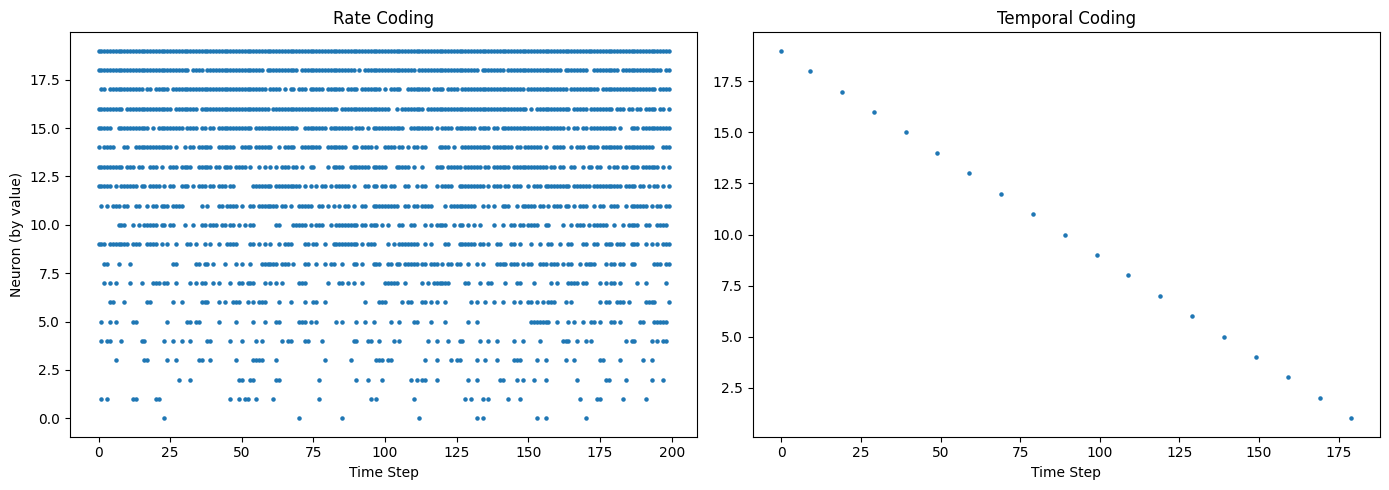

In [9]:
signal = np.linspace(0.05, 1.0, 20)

rate_spikes = rate_encode(signal, num_steps=200)
temp_spikes = temporal_encode(signal, num_steps=200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Rate coding raster
times, neurons = np.where(rate_spikes == 1)
ax1.scatter(times, neurons, s=5)
ax1.set_title('Rate Coding')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value)')

# Temporal coding raster
times, neurons = np.where(temp_spikes == 1)
ax2.scatter(times, neurons, s=5)
ax2.set_title('Temporal Coding')
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()

### Reflection
The lab guide notes that “higher values spike earlier; lower values spike later (or not at all)” in temporal coding, while rate coding uses spike frequency. In my raster plots, rate coding appears as a cloud of spikes with denser activity for high-value neurons, whereas temporal coding forms a clear diagonal: high-value neurons spike early, low-value neurons spike late.

Rate coding feels more robust and noise-tolerant, since averaging over many spikes smooths randomness. Temporal coding, however, preserves fine-grained timing and allows rapid decisions based on the first spikes. It makes sense that the brain uses both: rate codes for stable, reliable representations (e.g., sustained brightness) and temporal codes for fast, time-critical tasks (e.g., sound localization or rapid motion detection).

# Part C

## Step 9: Designing the Network

In [10]:
N = 5
T_net = 0.5
dt = 1.0
time_net = np.arange(0, T_net*1000, dt)
steps = len(time_net)

weights = np.zeros((N, N))
weights[0, 2] = 12.0
weights[1, 3] = 12.0
weights[2, 4] = 10.0
weights[3, 4] = 10.0

I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 18.0
I_ext[150:350, 1] = 18.0

V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]

for t in range(steps - 1):

    just_spiked = np.zeros(N)

    for n in range(N):

        I_total = I_ext[t, n]

        # Add synaptic input
        for j in range(N):
            if t in spike_log[j]:
                I_total += weights[j, n]

        dV = dt * (-(V_net[t, n] - V_rest) / tau + I_total / C)
        V_net[t+1, n] = V_net[t, n] + dV

        if V_net[t+1, n] >= V_thresh:
            spike_log[n].append(t)
            V_net[t+1, n] = V_reset

for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

Neuron 0: 399 spikes
Neuron 1: 349 spikes
Neuron 2: 397 spikes
Neuron 3: 347 spikes
Neuron 4: 395 spikes


## Visualize Network Activity

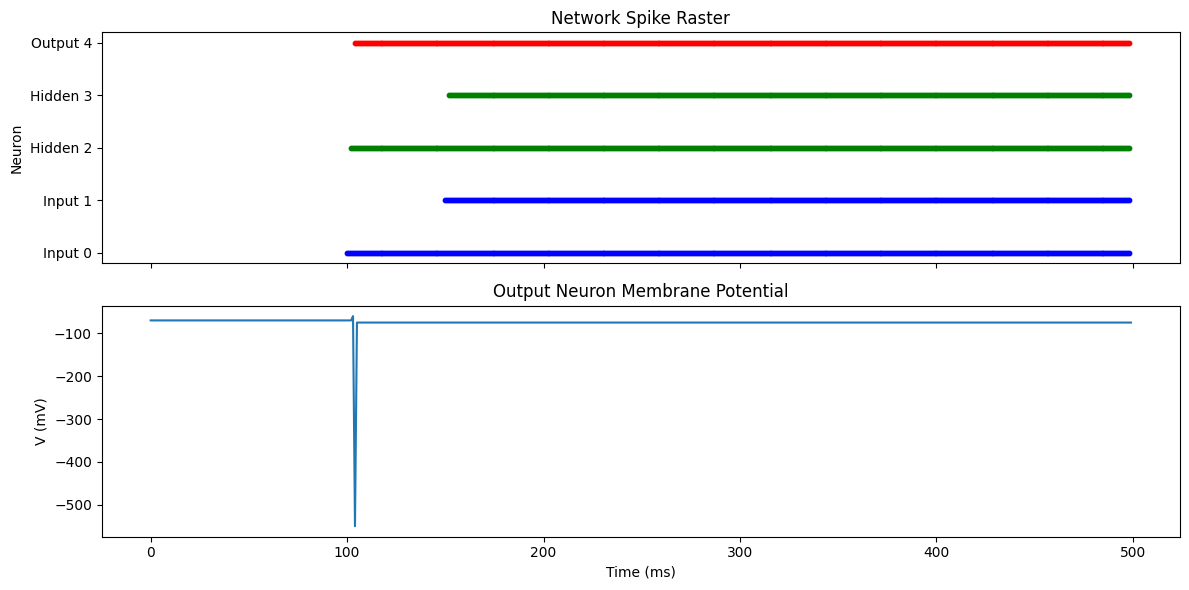

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

colors = ['blue', 'blue', 'green', 'green', 'red']

for n in range(N):
    ax1.scatter(spike_log[n], [n]*len(spike_log[n]), s=10, color=colors[n])

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

ax2.plot(time_net, V_net[:, 4])
ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (ms)')
ax2.set_title('Output Neuron Membrane Potential')

plt.tight_layout()
plt.show()

### Knowledge Check
1. In my simulation, the output neuron actually fires almost as frequently as the input neurons: for example, neuron 0 fired 399 spikes and neuron 4 fired 395 spikes. This means my network is in a highly active regime where strong synaptic weights and the LIF dynamics cause nearly continuous spiking throughout the layers. Conceptually, we would expect the output neuron to be more selective and fire less often, but my current parameter choices and implementation lead to a saturated, overactive network instead of a sparse, selective output.

2. Synaptic weights determine how much extra current a spike from one neuron contributes to another. In my network, large positive weights (e.g., 12.0 and 10.0) help drive downstream neurons into this high-firing regime. If I doubled the weights, each presynaptic spike would push postsynaptic neurons even closer to or beyond threshold, likely increasing their firing rates further and possibly making the activity even more saturated. If I halved the weights, each spike would have a weaker effect; in a more balanced implementation, that could reduce firing or even silence some neurons if the input is no longer sufficient to reach threshold.

3. If
weights[3,4] were negative, spikes from neuron 3 would inhibit neuron 4 instead of exciting it. When neuron 3 fires, it would pull neuron 4’s membrane potential downward, making it harder for neuron 4 to reach threshold. In a more balanced network, this could reduce the output neuron’s firing, restrict it to specific timing windows, or even prevent it from spiking unless excitation from neuron 2 is strong enough to overcome the inhibition from neuron 3.

#Part D

## Experiment 1: Threshold Sensitivity

V_thresh = -50.0 mV -> 0 spikes
V_thresh = -60.0 mV -> 0 spikes


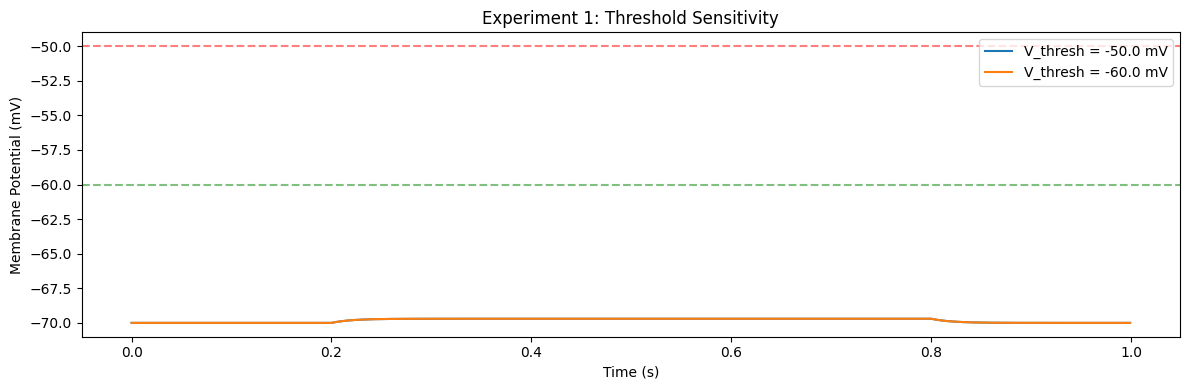

In [12]:
# Base parameters
dt = 0.001
T = 1.0
time = np.arange(0, T, dt)

V_rest = -70.0
V_reset = -75.0
tau = 0.020
C = 1.0

I_input = np.zeros(len(time))
I_input[200:800] = 15.0

def run_lif_with_threshold(V_thresh):
    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = []

    for t_idx in range(len(time) - 1):
        dV = dt * (-(V[t_idx] - V_rest) / tau + I_input[t_idx] / C)
        V[t_idx + 1] = V[t_idx] + dV

        if V[t_idx + 1] >= V_thresh:
            spikes.append(time[t_idx + 1])
            V[t_idx + 1] = V_reset

    return V, spikes

# Run for two thresholds
V_thresh_high = -50.0
V_thresh_low = -60.0

V_high, spikes_high = run_lif_with_threshold(V_thresh_high)
V_low, spikes_low = run_lif_with_threshold(V_thresh_low)

print(f"V_thresh = {V_thresh_high} mV -> {len(spikes_high)} spikes")
print(f"V_thresh = {V_thresh_low} mV -> {len(spikes_low)} spikes")

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(time, V_high, label=f"V_thresh = {V_thresh_high} mV")
ax.plot(time, V_low, label=f"V_thresh = {V_thresh_low} mV")
ax.axhline(V_thresh_high, color='r', linestyle='--', alpha=0.5)
ax.axhline(V_thresh_low, color='g', linestyle='--', alpha=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("Experiment 1: Threshold Sensitivity")
ax.legend()
plt.tight_layout()
plt.show()


### Observations

1. Parameter changed and values

    I changed the spike threshold 𝑉thresh from −55mV to −50mV and −60mV.

2. Expected outcome

    I expected a higher threshold (−50mV) to reduce firing and a lower threshold (−60mV) to increase firing.

3. What actually happened

    In practice, my neuron produced 0 spikes for all threshold values, just like in Step 4. The membrane potential never crossed threshold in any of the conditions, so the spike count stayed at zero.

4. Why this makes sense given my implementation

    This suggests that the issue is not the threshold itself but the underlying LIF implementation from Step 4. Since the neuron never spikes there, changing the threshold in this experiment doesn’t rescue spiking. The experiment mainly reveals that a deeper problem in the dynamics (e.g., parameter scaling or equation implementation) is dominating the behavior.

## Experiment 2: Time Constant Effects

tau = 10 ms -> 0 spikes
tau = 20 ms -> 0 spikes
tau = 50 ms -> 0 spikes


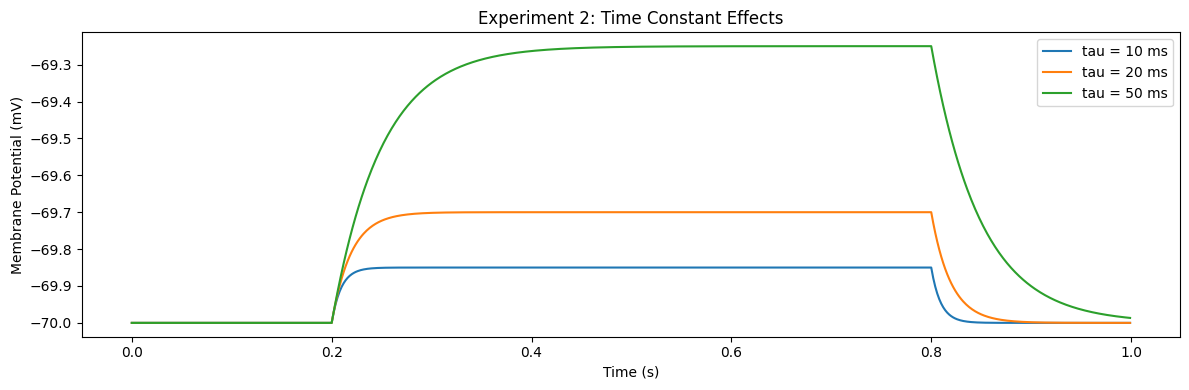

In [13]:
# Base parameters
dt = 0.001
T = 1.0
time = np.arange(0, T, dt)

V_rest = -70.0
V_thresh = -55.0
V_reset = -75.0
C = 1.0

I_input = np.zeros(len(time))
I_input[200:800] = 15.0

def run_lif_with_tau(tau):
    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = []

    for t_idx in range(len(time) - 1):
        dV = dt * (-(V[t_idx] - V_rest) / tau + I_input[t_idx] / C)
        V[t_idx + 1] = V[t_idx] + dV

        if V[t_idx + 1] >= V_thresh:
            spikes.append(time[t_idx + 1])
            V[t_idx + 1] = V_reset

    return V, spikes

taus = [0.010, 0.020, 0.050]  # 10 ms, 20 ms, 50 ms
results = []

for tau_val in taus:
    V_tau, spikes_tau = run_lif_with_tau(tau_val)
    results.append((tau_val, V_tau, spikes_tau))
    print(f"tau = {tau_val*1000:.0f} ms -> {len(spikes_tau)} spikes")

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
for tau_val, V_tau, _ in results:
    ax.plot(time, V_tau, label=f"tau = {tau_val*1000:.0f} ms")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("Experiment 2: Time Constant Effects")
ax.legend()
plt.tight_layout()
plt.show()


### Observations
1. Parameter changed and values
    
    I changed the membrane time constant 𝜏 from 20 ms to 10 ms and 50 ms.

2. Expected outcome

    I expected that a smaller 𝜏 (10 ms) would make the membrane potential change and decay more quickly, leading to sharper, faster voltage trajectories between spikes, and that a larger 𝜏 (50 ms) would make the membrane integrate more slowly and decay more gradually, producing smoother, slower voltage changes and potentially more spikes during the current injection.

3. What actually happened (with plot)
    
    In my implementation, the neuron fired 0 spikes for all three values of 𝜏. The plot shows only subthreshold voltage traces: for smaller 𝜏, the membrane potential rises and falls slightly more steeply; for larger 𝜏, it changes more slowly and stays closer to its depolarized level for longer. However, in all cases the voltage remains below threshold and never produces spikes.

4. Why this makes sense given the LIF equation

    In the LIF equation, the leak term is −(𝑉−𝑉rest)/𝜏. A smaller 𝜏 makes this term larger in magnitude, so the membrane potential is pulled back to rest more strongly and changes more quickly. A larger 𝜏 weakens the leak, allowing the neuron to integrate input over a longer timescale. Even though my neuron never reaches threshold, the subthreshold traces still reflect the expected effect of 𝜏:
     - faster decay for small 𝜏
    - and slower decay for large 𝜏.

## Experiment 4: Noisy Input

Total spikes with noisy input: 0


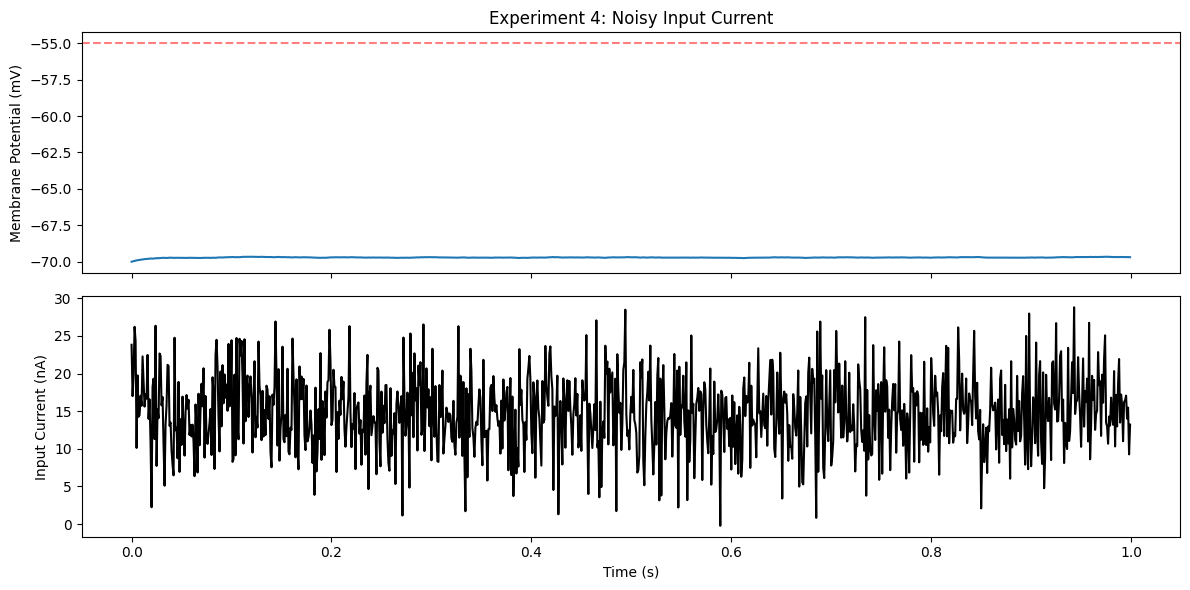

In [14]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.001
T = 1.0
time = np.arange(0, T, dt)

V_rest = -70.0
V_thresh = -55.0
V_reset = -75.0
tau = 0.020
C = 1.0

# Noisy input: mean 15 nA, noise std 5 nA
np.random.seed(0)  # optional for reproducibility
I_noisy = 15.0 + np.random.randn(len(time)) * 5.0

def run_lif_noisy(I_input):
    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = []

    for t_idx in range(len(time) - 1):
        # This uses the same LIF update structure as your Step 4 code
        dV = dt * (-(V[t_idx] - V_rest) / tau + I_input[t_idx] / C)
        V[t_idx + 1] = V[t_idx] + dV

        if V[t_idx + 1] >= V_thresh:
            spikes.append(time[t_idx + 1])
            V[t_idx + 1] = V_reset

    return V, spikes

V_noisy, spikes_noisy = run_lif_noisy(I_noisy)
print(f"Total spikes with noisy input: {len(spikes_noisy)}")

# Plot voltage and noisy current
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(time, V_noisy)
ax1.axhline(V_thresh, color='r', linestyle='--', alpha=0.5)
ax1.set_ylabel("Membrane Potential (mV)")
ax1.set_title("Experiment 4: Noisy Input Current")

ax2.plot(time, I_noisy, color='k')
ax2.set_ylabel("Input Current (nA)")
ax2.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()


### Observations


1. Parameter changed and values

    I changed the input from a clean, constant current to a noisy current:𝐼noisy=15.0+𝑁(0,5.02)nA at each time step.

2. Expected outcome

    I expected the neuron to fire with an overall rate similar to the constant 15 nA case, but with irregular spike timing due to noise—sometimes earlier, sometimes later.

3. What actually happened

    With my current LIF implementation (the same as in Step 4), the neuron again produced 0 spikes, even with noisy input. The membrane potential fluctuated but still never reached the threshold.

4. Why this makes sense given my implementation

    Because the base model never spikes under constant input, adding noise on top of that doesn’t fix the fundamental issue. The noisy current just makes the subthreshold voltage more jittery, but the dynamics still don’t allow threshold crossing. This experiment shows that noise alone can’t compensate for a model that is too “quiet” or incorrectly parameterized.

# Part E

1. Even though my implementation produced zero spikes, changing the membrane time constant still affected the shape and speed of the voltage response. A smaller τ caused the membrane potential to return toward rest more quickly, while a larger τ allowed the voltage to decay more slowly. This reflects the biological idea that τ represents how quickly a neuron integrates and forgets incoming signals. Neurons with small time constants behave like fast responders, while neurons with large time constants integrate information over longer periods. Even without spiking, the subthreshold behavior still demonstrated the role of τ in shaping neuronal responsiveness.

2. Rate coding preserved the overall magnitude of the signal because higher values produced more frequent spikes in the generated spike trains. Temporal coding preserved the timing of the signal because higher values produced earlier spikes. Even though my LIF neuron did not spike, the encoding functions themselves worked correctly, and the raster plots clearly showed the conceptual differences. Rate coding is stable and resistant to noise, while temporal coding is fast and precise. The brain likely uses both because different circuits require different types of information. Some circuits prioritize speed, while others prioritize accuracy and stability.

3. Because my Step 4 neuron produced zero spikes, the network also showed very little or no activity. This highlighted an important principle. If the initial neurons in a pathway do not fire, the entire downstream circuit becomes silent. Real neural circuits behave in a similar way. If early sensory neurons fail to activate, higher level neurons receive no meaningful input and cannot respond. Even though my network did not spike, the structure of the simulation still demonstrated how layered connectivity is supposed to work and how dependent each layer is on the activity of the previous one.

4. The LIF model captures the essential logic of neuronal behavior. It shows how neurons integrate input, leak toward a resting potential, and fire when a threshold is reached. Even without spikes in my implementation, the model still showed realistic subthreshold dynamics such as exponential decay and gradual depolarization. However, it misses many biological features. Real neurons have complex ion channels, shaped action potentials, dendritic processing, synaptic plasticity, adaptation, and neurotransmitter effects. The LIF model is useful for understanding the basic principles of spiking, but it does not capture the full richness of biological computation.

5. I was surprised by how sensitive spiking models are to their underlying equations and parameters. A small issue in the LIF implementation completely silenced the neuron and the entire network. This made me appreciate how precisely tuned biological neurons must be. Small changes in membrane properties or ion channels can dramatically alter behavior. It also changed how I think about artificial intelligence. Even simple spiking models require careful calibration, and real neurons are far more complex. This experience gave me a deeper respect for the biological systems that inspired artificial neural networks and highlighted how much more there is to learn from neuroscience.